In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn imbalanced-learn -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:

n_legit, n_fraud = 9700, 300


legit_feat = np.random.randn(n_legit, 10) * [1, 1.2, 0.9, 1.1, 0.8, 1.3, 1, 0.7, 1.1, 0.9]
fraud_feat = (np.random.randn(n_fraud, 10) * [1.5, 1, 1.8, 0.6, 2, 0.8, 1.5, 2.1, 0.5, 1.7]
              + [2, -1.5, 3, -2, 2.5, -1, 1.5, 2, -2, 1.5])

legit_amount = np.abs(np.random.lognormal(4.5, 1.0, n_legit))
fraud_amount = np.abs(np.random.lognormal(3.8, 1.2, n_fraud))
legit_time   = np.sort(np.random.uniform(0, 172800, n_legit))
fraud_time   = np.random.uniform(0, 172800, n_fraud)

X_legit = np.c_[legit_feat, legit_amount, legit_time]
X_fraud  = np.c_[fraud_feat, fraud_amount, fraud_time]
y_legit  = np.zeros(n_legit)
y_fraud  = np.ones(n_fraud)

X_raw = np.vstack([X_legit, X_fraud])
y_raw = np.concatenate([y_legit, y_fraud])

cols = [f'V{i}' for i in range(1, 11)] + ['Amount', 'Time']
df = pd.DataFrame(X_raw, columns=cols)
df['Class'] = y_raw.astype(int)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"\nClass Distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.2f}%")
df.head()

Dataset shape: (10000, 13)

Class Distribution:
Class
0    9700
1     300
Name: count, dtype: int64

Fraud rate: 3.00%


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Amount,Time,Class
0,-0.704812,1.252033,1.363491,-2.529987,-0.995597,-1.053117,0.723062,0.552225,0.571492,0.788756,474.335649,113586.035644,0
1,-0.239023,0.876235,0.377004,0.733867,0.482813,0.065156,-0.596204,-0.425429,-0.236111,0.758829,52.458956,85350.045161,0
2,-0.450668,2.711522,0.649046,0.281957,1.090837,0.392510,-0.505621,0.056112,1.142520,-1.792967,23.935014,31495.006841,0
3,-1.786495,-1.062204,-1.784611,-0.123820,-0.064630,-0.527155,0.538916,-0.506374,-1.427400,-0.717509,177.585765,86705.048866,0
4,0.479609,-0.129891,-1.417790,-0.553952,1.049259,0.379933,0.047291,-0.272156,-0.505953,0.489565,311.353059,82636.250369,0


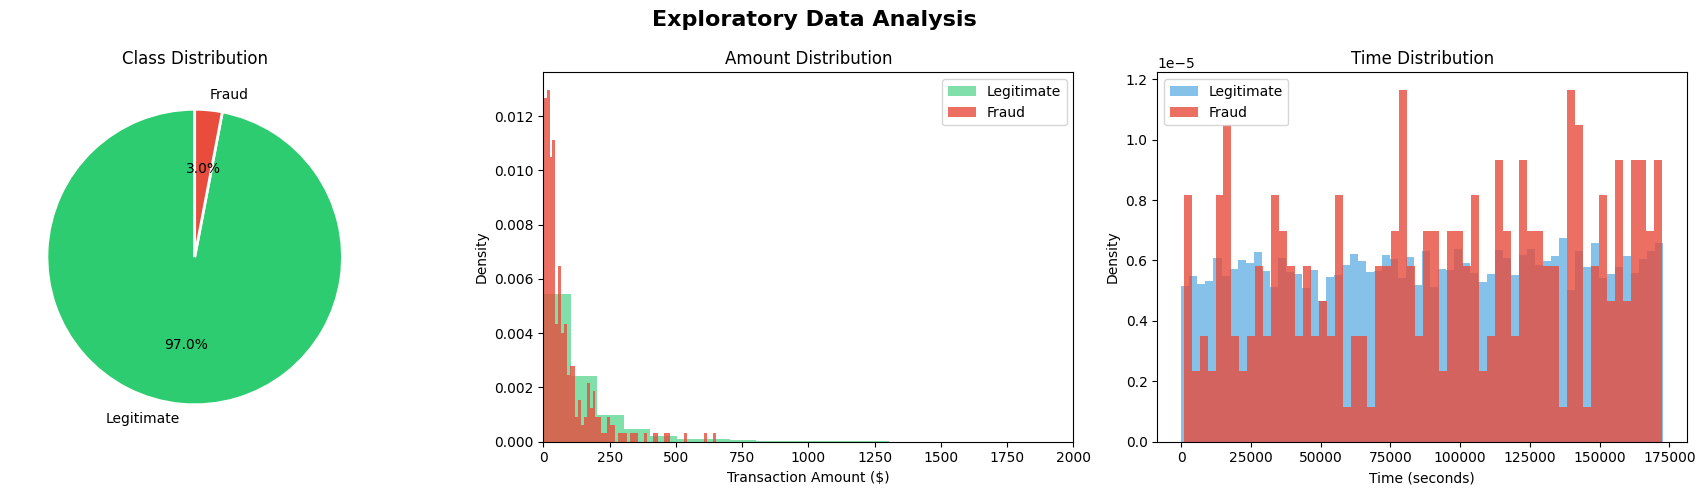

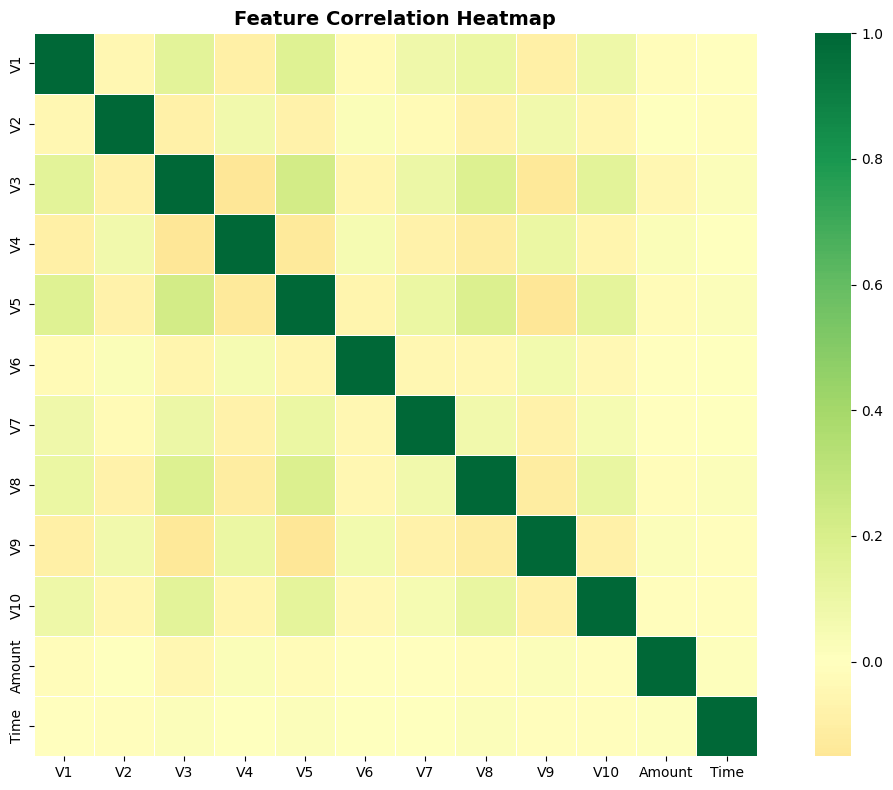

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')


axes[0].pie([n_legit, n_fraud],
            labels=['Legitimate', 'Fraud'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution')


axes[1].hist(df[df.Class==0]['Amount'], bins=60, color='#2ecc71', alpha=0.6,
             label='Legitimate', density=True)
axes[1].hist(df[df.Class==1]['Amount'], bins=60, color='#e74c3c', alpha=0.8,
             label='Fraud', density=True)
axes[1].set_xlabel('Transaction Amount ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Amount Distribution')
axes[1].legend()
axes[1].set_xlim(0, 2000)


axes[2].hist(df[df.Class==0]['Time'], bins=60, color='#3498db', alpha=0.6,
             label='Legitimate', density=True)
axes[2].hist(df[df.Class==1]['Time'], bins=60, color='#e74c3c', alpha=0.8,
             label='Fraud', density=True)
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Density')
axes[2].set_title('Time Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
corr = df.drop('Class', axis=1).corr()
sns.heatmap(corr, cmap='RdYlGn', center=0, annot=False,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

feature_cols = [f'V{i}' for i in range(1, 11)] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols].values
y = df['Class'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Before SMOTE → Train: {X_train.shape}, Fraud: {y_train.sum():.0f}")


smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE → Train: {X_train_bal.shape}, Fraud: {y_train_bal.sum():.0f}")
print(f"Test set      → {X_test.shape}, Fraud: {y_test.sum():.0f}")

Before SMOTE → Train: (8000, 12), Fraud: 240
After  SMOTE → Train: (15520, 12), Fraud: 7760
Test set      → (2000, 12), Fraud: 60


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                       learning_rate=0.1, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"\n Training: {name} ...")
    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc_roc = roc_auc_score(y_test, y_prob)
    auc_pr  = average_precision_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)
    cv_f1   = cross_val_score(model, X_train_bal, y_train_bal,
                               cv=cv, scoring='f1').mean()
    cm      = confusion_matrix(y_test, y_pred)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'f1': f1, 'cv_f1': cv_f1, 'cm': cm
    }
    print(f"   ROC-AUC : {auc_roc:.4f}")
    print(f"   PR-AUC  : {auc_pr:.4f}")
    print(f"   F1-Score: {f1:.4f}")
    print(f"   CV-F1   : {cv_f1:.4f}")

best_name = max(results, key=lambda k: results[k]['auc_roc'])
print(f"\n Best Model: {best_name}  (ROC-AUC = {results[best_name]['auc_roc']:.4f})")


 Training: Logistic Regression ...
   ROC-AUC : 0.9996
   PR-AUC  : 0.9905
   F1-Score: 0.9355
   CV-F1   : 0.9979

 Training: Decision Tree ...
   ROC-AUC : 0.9480
   PR-AUC  : 0.7982
   F1-Score: 0.9000
   CV-F1   : 0.9961

 Training: Random Forest ...
   ROC-AUC : 0.9992
   PR-AUC  : 0.9852
   F1-Score: 0.9412
   CV-F1   : 0.9997

 Training: Gradient Boosting ...
   ROC-AUC : 0.9994
   PR-AUC  : 0.9865
   F1-Score: 0.9421
   CV-F1   : 0.9992

 Best Model: Logistic Regression  (ROC-AUC = 0.9996)


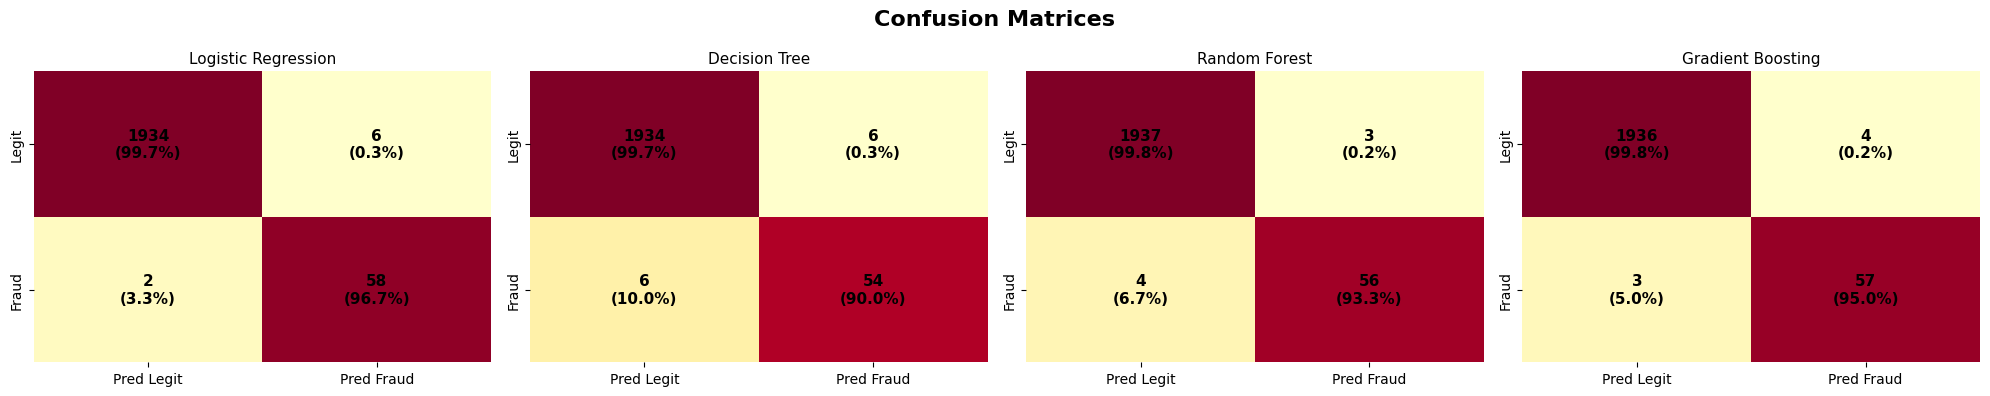

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = res['cm']
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_pct, annot=False, cmap='YlOrRd', ax=ax,
                vmin=0, vmax=100, cbar=False)
    for r in range(2):
        for c in range(2):
            ax.text(c + 0.5, r + 0.5,
                    f'{cm[r,c]}\n({cm_pct[r,c]:.1f}%)',
                    ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Pred Legit', 'Pred Fraud'])
    ax.set_yticklabels(['Legit', 'Fraud'])
    ax.set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

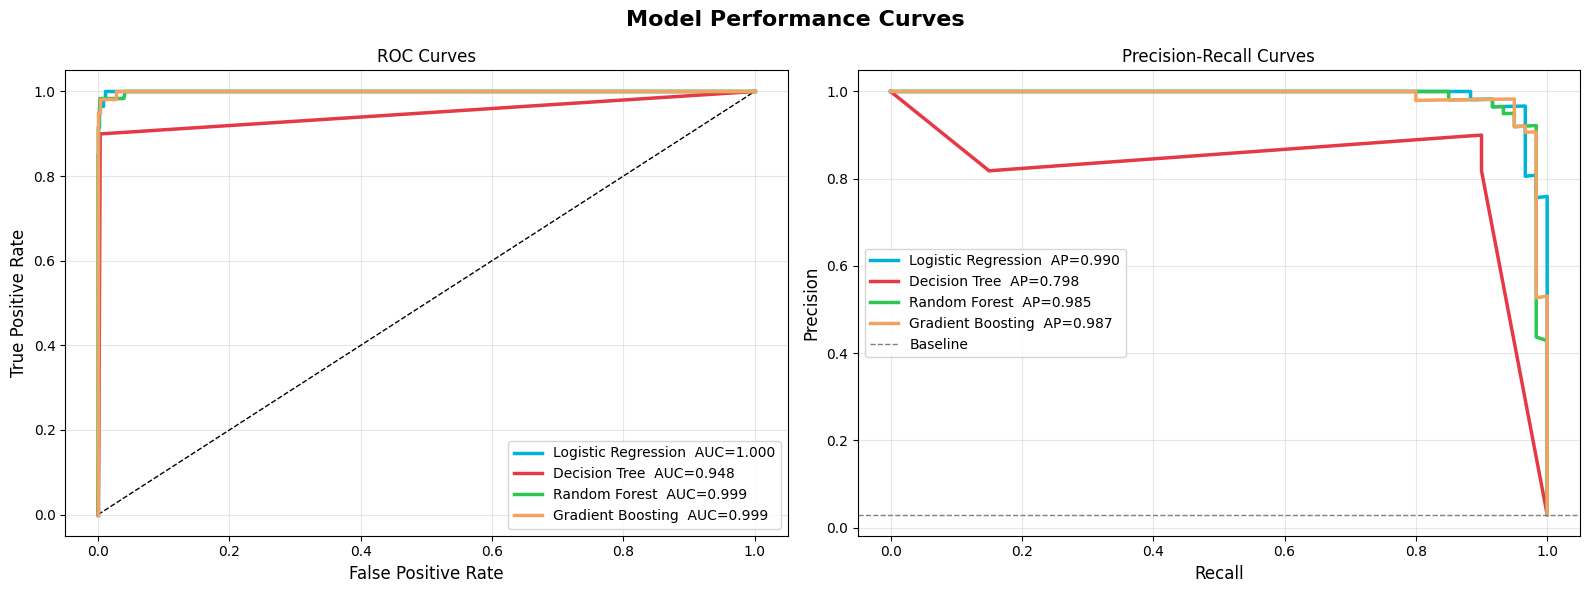

In [ ]:
COLORS = ['#00b4d8', '#e63946', '#2dc653', '#f4a261']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Curves', fontsize=16, fontweight='bold')


ax1.plot([0, 1], [0, 1], 'k--', lw=1)
for (name, res), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, color=color, lw=2.5,
             label=f"{name}  AUC={res['auc_roc']:.3f}")
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)


for (name, res), color in zip(results.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax2.plot(rec, prec, color=color, lw=2.5,
             label=f"{name}  AP={res['auc_pr']:.3f}")
ax2.axhline(y=df['Class'].mean(), color='gray', linestyle='--',
            lw=1, label='Baseline')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

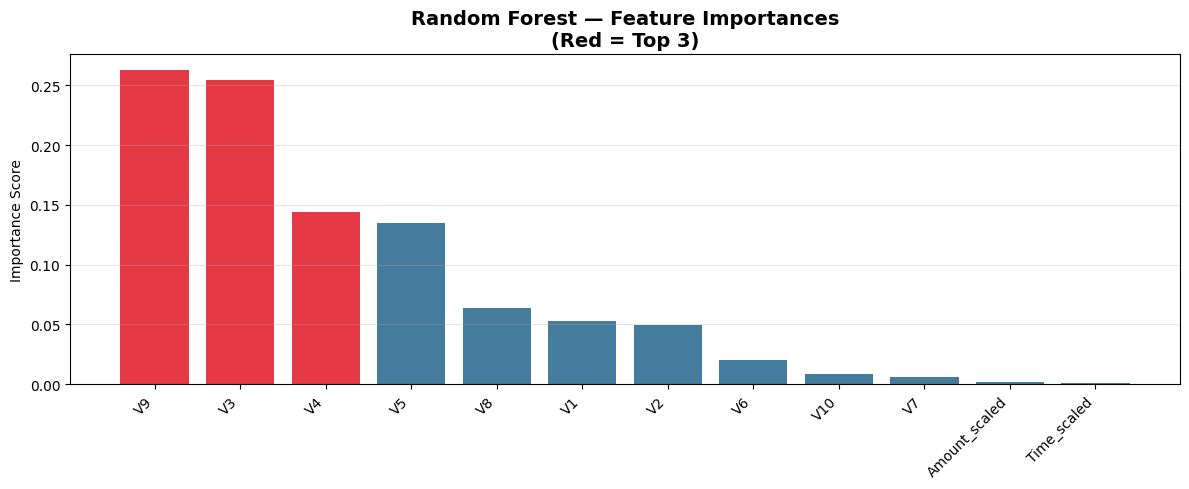

In [ ]:
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(feature_cols)),
               importances[indices],
               color=['#e63946' if i < 3 else '#457b9d' for i in range(len(indices))])
plt.xticks(range(len(feature_cols)),
           [feature_cols[i] for i in indices],
           rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.title('Random Forest — Feature Importances\n(Red = Top 3)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 65)
print(f"{'MODEL COMPARISON SCORECARD':^65}")
print("=" * 65)
print(f"{'Model':<22} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1':>8} {'CV-F1':>8}  {'Best?':>6}")
print("-" * 65)

for name, res in results.items():
    star = "⭐ YES" if name == best_name else ""
    print(f"{name:<22} {res['auc_roc']:>8.4f} {res['auc_pr']:>8.4f} "
          f"{res['f1']:>8.4f} {res['cv_f1']:>8.4f}  {star}")

print("=" * 65)
print(f"\n🏆 BEST MODEL: {best_name}")
print("=" * 65)
print(classification_report(
    y_test,
    results[best_name]['y_pred'],
    target_names=['Legitimate', 'Fraud']
))

                   MODEL COMPARISON SCORECARD                    
Model                   ROC-AUC   PR-AUC       F1    CV-F1   Best?
-----------------------------------------------------------------
Logistic Regression      0.9996   0.9905   0.9355   0.9979  ⭐ YES
Decision Tree            0.9480   0.7982   0.9000   0.9961  
Random Forest            0.9992   0.9852   0.9412   0.9997  
Gradient Boosting        0.9994   0.9865   0.9421   0.9992  

🏆 BEST MODEL: Logistic Regression
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1940
       Fraud       0.91      0.97      0.94        60

    accuracy                           1.00      2000
   macro avg       0.95      0.98      0.97      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
def predict_transaction(features: list, model_name: str = best_name):
    """
    Predict if a single transaction is fraudulent.
    features: list of 12 values [V1..V10, Amount, Time]
    """
    model = results[model_name]['model']


    arr = np.array(features).reshape(1, -1)
    arr[0, 10] = (arr[0, 10] - df['Amount'].mean()) / df['Amount'].std()
    arr[0, 11] = (arr[0, 11] - df['Time'].mean())   / df['Time'].std()

    prob  = model.predict_proba(arr)[0, 1]
    label = "FRAUD" if prob >= 0.5 else " LEGITIMATE"
    print(f"Model     : {model_name}")
    print(f"Fraud Prob: {prob:.4f} ({prob*100:.2f}%)")
    print(f"Decision  : {label}")
    return prob


suspicious_txn = [2.1, -1.4, 3.2, -1.8, 2.6, -0.9, 1.7, 2.3, -1.9, 1.6, 150.0, 50000.0]
predict_transaction(suspicious_txn)

Model     : Logistic Regression
Fraud Prob: 1.0000 (100.00%)
Decision  : FRAUD


np.float64(0.9999633139755083)